INSTALL LIBRARY

In [1]:
!pip install -q \
transformers==4.46.3 \
huggingface_hub==0.26.2 \
tokenizers==0.20.3 \
datasets==3.1.0 \
accelerate==1.1.1 \
evaluate==0.4.3 \
sentencepiece \
openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.26.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.9.0 w

IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import torch

import transformers
import huggingface_hub

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

PERIKSA RUNTIME

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


PERIKSA VERSI

In [3]:
import transformers
import datasets
import huggingface_hub

print(transformers.__version__)
print(datasets.__version__)
print(huggingface_hub.__version__)

4.46.3
3.1.0
0.26.2


LOAD TOKENIZER

In [4]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer berhasil")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer berhasil


LOAD MODEL

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)

print("Model berhasil")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model berhasil


# **LOAD MODEL DILAKUKAN DIAWAL KARENA PADA PROSES LOAD MODEL SERINGKALI MENGALAMI MASALAH SEHINGGA DITEMPATKAN DI STEP PERTAMA UNTUK MENGHEMAT WAKTU**

LOAD DATASET

In [6]:
data = pd.read_excel("dataset_final_mbg.xlsx")

MEMILIH ASPEK

In [7]:
ASPEK = "GIZI"
LABEL = "LABEL GIZI"

MENGAMBIL KOLOM YANG MAU DIPAKAI

In [8]:
data = data[[ASPEK, LABEL]]

data.columns = [
    "text",
    "label"
]

data = data.dropna().reset_index(drop=True)

data.head()

,text,label
0,cukup karena dalam satu waktu memiliki banyak ...,1
1,sudah sesuai 4 sehat 5 sempurna,1
2,menurut saya kurang memenuhi asupan gizi haria...,-1
3,enak bergizi,1
4,kandungan gizinya seimbang,1


MAPPING LABEL : INDOBERT TIDAK BOLEH PAKAI -1 0 1, HARUS 0 1 2

In [9]:
label_map = {
    -1:0,
     0:1,
     1:2
}

data["label"] = data["label"].map(label_map)

CEK KEMBALI

In [10]:
data.head()

print()

print(data["label"].value_counts())


label
2    99
0    48
1    22
Name: count, dtype: int64


## **TOKENIZER INDOBERT**

TRAIN TEST SPLIT

In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)

print("Train :", len(train_df))
print("Test  :", len(test_df))

Train : 135
Test  : 34


UBAH MENJADI HUGGINGFACE DATASET

In [12]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 135
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 34
})


FUNGSI TOKENISASI

In [13]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

TOKENISASI DATASET

In [14]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/135 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

FORMAT DATASET

In [15]:
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

HAPUS KOLOM KOSONG

In [16]:
train_dataset = train_dataset.remove_columns(["__index_level_0__"])
test_dataset = test_dataset.remove_columns(["__index_level_0__"])

CEK HASIL

In [17]:
train_dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 135
})

RENAME LABEL JADI LABELS

In [18]:
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

AKURASI METRIK

In [19]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

DATA COLLATOR

In [20]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

TRAINING ARGUMENT

In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./hasil_indobert",

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=10,

    weight_decay=0.01,

    logging_steps=5,

    seed=42,

    report_to="none"
)

EARLY STOPPING

In [22]:
from transformers import EarlyStoppingCallback

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2
)

TRAINER

In [23]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

/tmp/ipykernel_1217/4225595889.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [24]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.818900,0.534691,0.852941
2,0.370700,0.335788,0.882353
3,0.183400,0.266549,0.911765
4,0.054300,0.371916,0.911765
5,0.012200,0.365839,0.911765


TrainOutput(global_step=85, training_loss=0.312912242815775, metrics={'train_runtime': 147.4243, 'train_samples_per_second': 9.157, 'train_steps_per_second': 1.153, 'total_flos': 44400389241600.0, 'train_loss': 0.312912242815775, 'epoch': 5.0})

VISUALISASI GRAFIK TRAINING

In [25]:
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.0110,5.806440,0.000019,0.294118,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.8816,10.912745,0.000019,0.588235,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.8189,7.229215,0.000018,0.882353,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,1.000000,17,0.534691,0.852941,0.2657,127.954,18.817,NaN,NaN,NaN,NaN,NaN
4,0.5346,5.162004,0.000018,1.176471,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


GRAFIK TRAINING LOSS

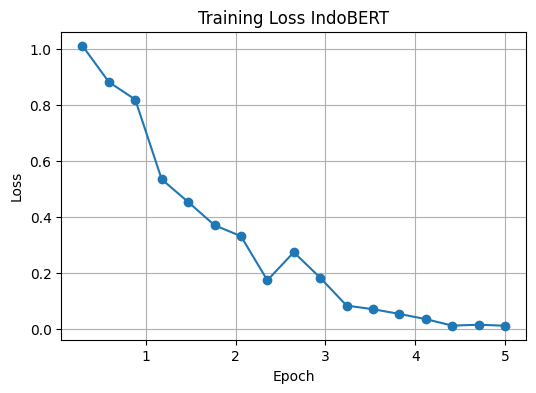

In [26]:
import matplotlib.pyplot as plt

loss = history.dropna(subset=["loss"])

plt.figure(figsize=(6,4))

plt.plot(
    loss["epoch"],
    loss["loss"],
    marker="o"
)

plt.title("Training Loss IndoBERT")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

GRAFIK VALIDATION ACCURACY

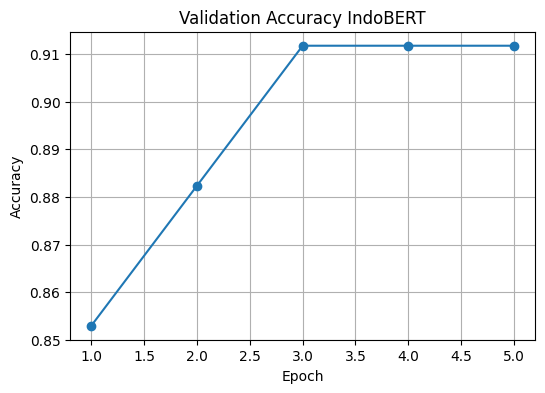

In [27]:
eval_acc = history.dropna(subset=["eval_accuracy"])

plt.figure(figsize=(6,4))

plt.plot(
    eval_acc["epoch"],
    eval_acc["eval_accuracy"],
    marker="o"
)

plt.title("Validation Accuracy IndoBERT")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

PREDIKSI

In [28]:
predictions = trainer.predict(test_dataset)

AMBIL HASIL PREDIKSI

In [29]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

ACCURACY, PRECISION, F1 SCORE

In [30]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_true, y_pred))

print()

print(classification_report(
    y_true,
    y_pred,
    digits=4
))

Accuracy : 0.9117647058823529

              precision    recall  f1-score   support

           0     0.8333    1.0000    0.9091        10
           1     0.7500    0.7500    0.7500         4
           2     1.0000    0.9000    0.9474        20

    accuracy                         0.9118        34
   macro avg     0.8611    0.8833    0.8688        34
weighted avg     0.9216    0.9118    0.9129        34



CONFUSION MATRIX

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[10  0  0]
 [ 1  3  0]
 [ 1  1 18]]


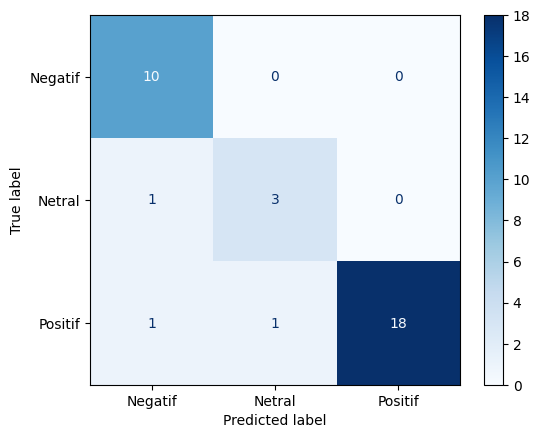

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negatif","Netral","Positif"]
)

disp.plot(cmap="Blues")

plt.show()

MAPPING LABEL KEMBALI

In [33]:
label_map = {
    0:"Negatif",
    1:"Netral",
    2:"Positif"
}

print(label_map[y_pred[0]])

Positif


FUNGSI PREDIKSI KALIMAT BARU

In [34]:
import torch

id2label = {
    0: "Negatif",
    1: "Netral",
    2: "Positif"
}

def prediksi_sentimen(teks):
    model.eval()

    inputs = tokenizer(
        teks,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    if torch.cuda.is_available():
        model.cuda()
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred]

In [35]:
kalimat = input("Masukkan kalimat: ")

print(prediksi_sentimen(kalimat))

Masukkan kalimat: kurang bergizi
Negatif


In [36]:
trainer.save_model("model_indobert_gizi")
tokenizer.save_pretrained("model_indobert_gizi")

('model_indobert_gizi/tokenizer_config.json',
 'model_indobert_gizi/special_tokens_map.json',
 'model_indobert_gizi/vocab.txt',
 'model_indobert_gizi/added_tokens.json',
 'model_indobert_gizi/tokenizer.json')

In [37]:
import torch

id2label = {
    0: "Negatif",
    1: "Netral",
    2: "Positif"
}

def prediksi_sentimen(teks):
    model.eval()

    inputs = tokenizer(
        teks,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    if torch.cuda.is_available():
        model.cuda()
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred]

In [39]:
print(prediksi_sentimen("tidak bergizi"))
print(prediksi_sentimen("sangat bergizi"))
print(prediksi_sentimen("biasa saja"))

Negatif
Positif
Netral
